# Python Plot Reference 

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

## Stacked Bar Plot
Reference:  https://www.pythoncharts.com/python/stacked-bar-charts/#seaborn-stacked-bar-charts

In [11]:
tips = sns.load_dataset('tips')
agg_tips = tips.groupby(['day', 'sex'])['tip'].sum().unstack().fillna(0)
agg_tips

sex,Male,Female
day,,
Thur,89.41,82.42
Fri,26.93,25.03
Sat,181.95,78.45
Sun,186.78,60.61


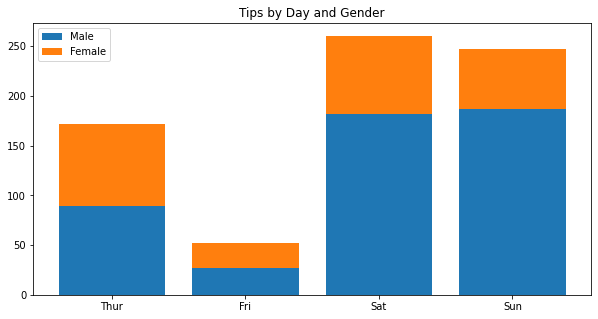

In [9]:
fig, ax = plt.subplots( figsize=(10,5) )     # define plot space 

# plot the 'Male' bars for every day:
ax.bar( agg_tips.index, 
        agg_tips['Male'], 
        label='Male'
      )  
# plot the 'Female' bars on top of the male bars:
ax.bar( agg_tips.index,
        agg_tips['Female'],
        bottom=agg_tips['Male'],
        label='Female'
      )
ax.set_title('Tips by Day and Gender')
ax.legend()

<AxesSubplot:xlabel='day'>

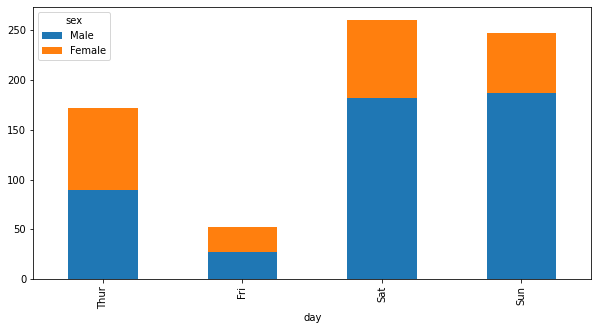

In [12]:
# alternative stacked barplot using pandas:
agg_tips.plot.bar( stacked=True, figsize=(10,5) )

# also useful:
#makeplot = agg_tips.plot.bar( stacked=True, figsize=(10,5) )
#makeplot.get_figure().savefig('output.jpg', format='jpg')

# Multiple Line Plot

       pig  horse
1990    20      4
1997    18     25
2003   489    281
2009   675    600
2014  1776   1900


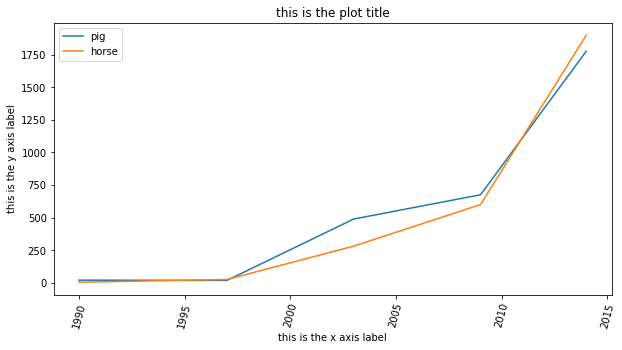

In [13]:
df = pd.DataFrame({
   'pig': [20, 18, 489, 675, 1776],
   'horse': [4, 25, 281, 600, 1900]
   }, index=[1990, 1997, 2003, 2009, 2014])
print( df )
lines = df.plot.line(
            rot = 75,          # rotate x-axis labels 75 degrees
            title = 'this is the plot title',
            xlabel = 'this is the x axis label',
            ylabel = 'this is the y axis label',
            figsize = (10,5)            # (width,height)
)

# Faceted Multiple Line Plot

    align choice  time  coherence  firing_rate
311  dots     T2   300       12.8    37.795854
708  sacc     T2  -160       25.6    32.345581
185  dots     T1   620        6.4    58.431330
385  dots     T2   640        6.4    37.852326
122  dots     T1   320       12.8    50.547571
409  sacc     T1  -460        3.2    47.063536
103  dots     T1   260        3.2    46.480672
436  sacc     T1  -320        3.2    51.715666
363  dots     T2   520        3.2    38.768191
62   dots     T1   120        6.4    31.968215


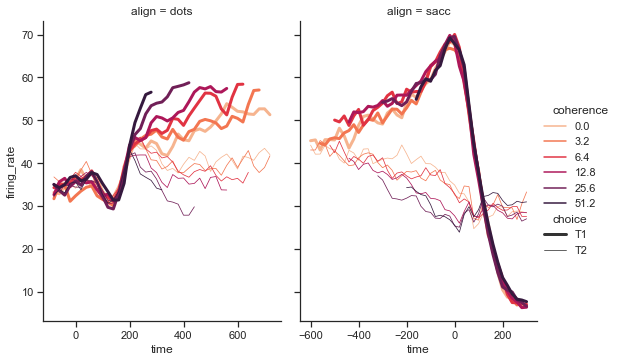

In [9]:
#import seaborn as sns
sns.set_theme(style="ticks")

#dots = sns.load_dataset("dots")
print( dots.sample(10) )

# Define the palette as a list to specify exact values
#palette = sns.color_palette("rocket_r")

# Plot the lines on two facets
sns.relplot(
    data=dots,
    x="time", y="firing_rate",
    hue="coherence", size="choice", col="align",
    kind="line", size_order=["T1", "T2"], palette=palette,
    height=5, aspect=.75, facet_kws=dict(sharex=False),
)

    time facet linegroup     value
0      0     A         v  0.667744
1      1     A         v  0.243047
2      2     A         v  0.275094
3      0     A         w  0.963285
4      1     A         w  0.650151
5      2     A         w  0.433625
6      0     B         x  0.561170
7      1     B         x  0.189637
8      2     B         x  0.577428
9      0     B         y  0.563189
10     1     B         y  0.917294
11     2     B         y  0.337510
12     0     C         z  0.835800
13     1     C         z  0.174003
14     2     C         z  0.120558


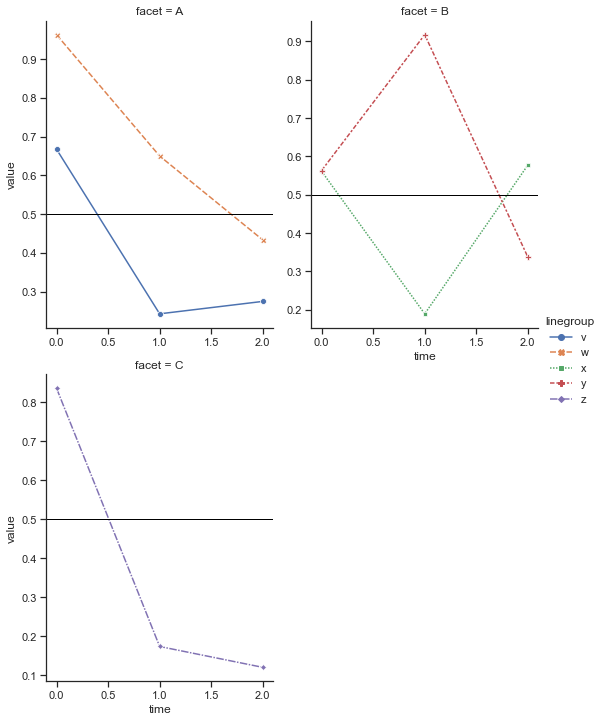

In [54]:
data_for_plot = pd.DataFrame(
    {
        'time':[0,1,2, 0,1,2, 0,1,2, 0,1,2, 0,1,2],
        'facet':['A','A','A', 'A','A','A', 'B','B','B', 'B','B','B', 'C','C','C'],
        'linegroup':['v','v','v', 'w','w','w', 'x','x','x', 'y','y','y', 'z','z','z'],
        'value':np.random.uniform(0,1,size=15)
    }
)

print( data_for_plot )

graph = sns.relplot(
         data = data_for_plot,
            x = 'time', 
            y = 'value',
          col = 'facet',
         kind = 'line',  
          hue = 'linegroup',
        style = 'linegroup',
      markers = True,
       height = 5, 
       aspect = 0.75, 
     col_wrap = 2,                                    # make facet-grid 2 plots wide
    facet_kws = dict( sharex=False, sharey=False)     # arguments passed to sns.FacetGrid
)

# add same horizontal line to each facet:
axes = graph.axes.flatten()
for ax in axes:
    ax.axhline(0.5, ls='-', linewidth=1, color='black')

# HeatMap

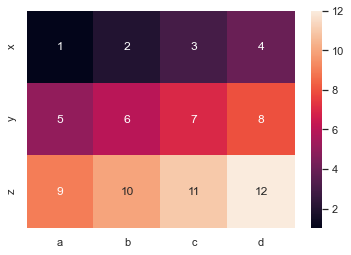

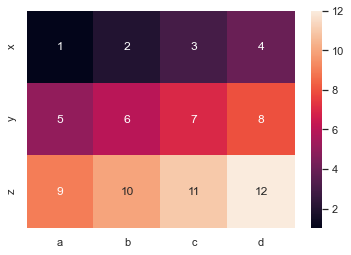

In [4]:
# https://seaborn.pydata.org/generated/seaborn.heatmap.html

import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
#import pandas as pd

sns.set_theme()

data_for_heatmap = np.array(
    [
        [ 1, 2, 3, 4],
        [ 5, 6, 7, 8],
        [ 9, 10, 11, 12]
    ]
)

ax = sns.heatmap( 
    data_for_heatmap,
    annot = True 
)
ax.set_xticklabels( ['a','b','c','d'])
ax.set_yticklabels( ['x','y','z'])

plt.show() 

# same heatmap as above, but with data provided as pandas dataframe:
pandas_df_data_for_heatmap = pd.DataFrame(
    {
        'a':[1,5,9],
        'b':[2,6,10],
        'c':[3,7,11],
        'd':[4,8,12]
    },
    index = ['x','y','z']
)

ax = sns.heatmap( 
    pandas_df_data_for_heatmap,
    annot = True 
)

plt.show()